In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import os

/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
DATA_DIR = "/home/gokulg/orcd/scratch/lt/data/"
OUT_DIR = "models/qiu2022_scvi/"
ANNOTATION_FILE = os.path.join(DATA_DIR, "annotation_v5.csv")
TYPES_TO_REMOVE = ["doublet"]

In [3]:
# adata = sc.read_h5ad("/mnt/home/gokulg/data/embryos/qiu2022.h5ad")
# cc = sc.read_h5ad("/mnt/home/gokulg/data/embryos/combined_counts.h5ad")

adata = sc.read_h5ad("/home/gokulg/orcd/scratch/lt/data/qiu2022_combined.h5ad")
cc = sc.read_h5ad("/home/gokulg/orcd/scratch/lt/data/embryos/combined_counts.h5ad")

In [4]:


hvgs = pd.read_csv(f"{DATA_DIR}hvg_v5.csv", header=None)[0].tolist()
conversion = pd.read_csv(f"{DATA_DIR}mm39_annotations.csv", header=0)
gene_symbols = pd.read_csv(f"{DATA_DIR}gene_symbols.tsv", sep='\t', header=0)

In [5]:
conversion_dict = {}

# for i, row in conversion.iterrows():
#     conversion_dict[row['gene_ids']] = row['gene_name']
#     conversion_dict[row['gene_name']] = row['gene_ids']
#     conversion_dict[row['gene_ids'].split('.')[0]] = row['gene_name']

for i, row in gene_symbols.iterrows():
    conversion_dict[row['Gene stable ID']] = row['MGI symbol']
    conversion_dict[row['MGI symbol']] = row['Gene stable ID']
    conversion_dict[row['Gene stable ID'].split('.')[0]] = row['MGI symbol']
    
adata.var_names = adata.var['features'].tolist()
adata.var_names = [str(conversion_dict.get(v, v)) for v in adata.var_names]
adata.var_names_make_unique()

In [6]:

adata_hvg = adata[:, [h for h in hvgs if h in adata.var_names]].copy()
cc_hvg = cc[:, [h for h in adata_hvg.var_names]].copy()
cc_hvg.obs['time'] = [float(x.split('-')[0][1:]) for x in cc_hvg.obs['embryo'].values]

# add annotations and remove unwanted types
annotations = pd.read_csv(ANNOTATION_FILE, index_col=0)
cc_hvg.obs = cc_hvg.obs.join(annotations, how="left")
cc_hvg = cc_hvg[~cc_hvg.obs["annotation"].isin(TYPES_TO_REMOVE)].copy()


cc_hvg = cc_hvg[cc_hvg.obs['time'] < 8.6, :].copy()


# check that data are integer counts
assert [(adata_hvg.X.data[:10].astype(int) == adata_hvg.X.data[:10]).all()]
assert [(cc_hvg.X.data[:10].astype(int) == cc_hvg.X.data[:10]).all()]

overlapping_days = ['E6.5', 'E6.75', 'E7.0', 'E7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5a',]
adata_hvg_overlap = adata_hvg[adata_hvg.obs['day'].isin(overlapping_days)].copy()
combined = ad.concat([adata_hvg_overlap, cc_hvg], axis='obs', join='outer', label='dataset', keys=['qiu2022', 'devmap'])

In [7]:
# save counts in layers counts
combined.layers["counts"] = combined.X.copy()
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)

In [ ]:
sc.tl.rank_genes_groups(combined, 'dataset', method='wilcoxon')
top_genes_df = sc.get.rank_genes_groups_df(combined, group=None, key='rank_genes_groups')

k = 100
top_k = top_genes_df.groupby('group').head(k)

gene_subset = [x for x in combined.var_names if x not in top_k['names'].values]
combined = combined[:, gene_subset].copy()

combined

/tmp/ipykernel_1499053/955438268.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_k = top_genes_df.groupby('group').head(k)


AnnData object with n_obs × n_vars = 194371 × 2635
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'day', 'group', 'cell_state', 'cell_type', 'somite_stage', 'capture', 'cellBC', 'embryo', 'type', 'n_genes_by_counts', 'total_counts', 'detection_rate', 'clade', 'clone', 'time', 'annotation', 'dataset'
    uns: 'log1p', 'rank_genes_groups'
    layers: 'counts'

In [9]:
setup_kwargs = {}
setup_kwargs['categorical_covariate_keys'] = ['dataset']
scvi.model.SCVI.setup_anndata(combined, layer='counts', **setup_kwargs)

In [10]:
model = scvi.model.SCVI(
    combined, 
    n_layers=2, 
    n_latent=50,
    n_hidden=512,
    gene_likelihood='nb',
    dispersion='gene-batch'
)

In [11]:
model.train(
    max_epochs=100, early_stopping=False,
    # plan_kwargs={'kl_weight' : 1},
)

/home/gokulg/.local/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /orcd/home/002/gokulg/miniforge3/envs/lineage/lib/py ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/gokulg/.local/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /orcd/home/002/gokulg/miniforge3/envs/lineage/lib/py ...
You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for p

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [12]:
model.save(os.path.join(OUT_DIR, "scvi_model"), overwrite=True)
combined.obsm["X_scvi"] = model.get_latent_representation()
print(f"embeddings computed, shape: {combined.obsm['X_scvi'].shape}")

# subsample for umap
n_sub = min(500_000, combined.shape[0])
idx = np.random.choice(combined.shape[0], size=n_sub, replace=False)
combined_sub = combined[idx].copy()


tag = 'qiu2022_scvi'
# compute and save umaps
sc.pp.neighbors(combined_sub, use_rep="X_scvi")
sc.tl.umap(combined_sub)

embeddings computed, shape: (194371, 50)


/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


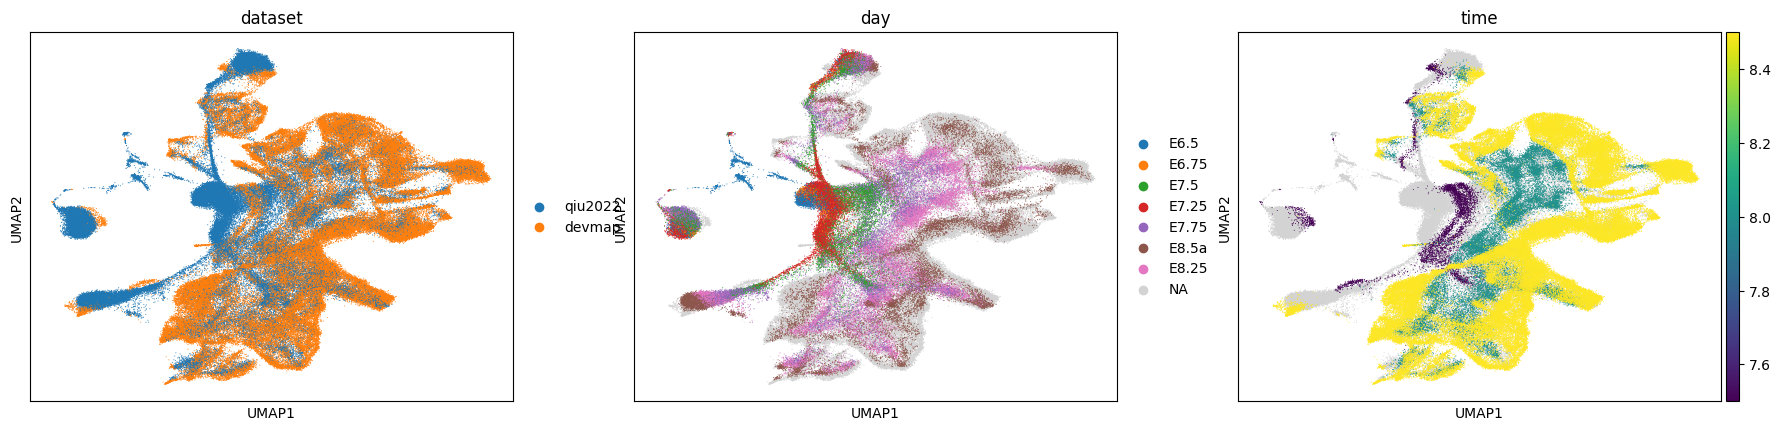

In [17]:
sc.pl.umap(combined_sub, color=["dataset", "day", "time"], size=2, hspace=0.6)

In [18]:
combined.write_h5ad(os.path.join(DATA_DIR, "qiu2022_integrated_scvi.h5ad"))